# Strikeouts in Baseball
One of the best ways to improve your data visualization skills is to try and replicate great visualizations you see out there. Using the dataset provided in this template, you can take a look at how to recreate some amazing visualizations using Python so that you can take your data visualization skills to the next level.

You can try and replicate following sports piece published by the New York Times in 2012. It is a beautiful visualization illustrating how strikeouts were on the rise. The visualization showcases the strikeouts per game by team as well as the aggregated strikeouts per game for the whole league. Read the [original article](https://archive.nytimes.com/www.nytimes.com/interactive/2013/03/29/sports/baseball/Strikeouts-Are-Still-Soaring.html?ref=baseball) to get more context, and analyze the visualization carefully before attempting to replicate it.  

![Strikeouts on the Rise](images/reference_plot.png)

The data for this visualization comes from an [excellent database](http://www.seanlahman.com/baseball-archive/statistics/) compiled by Sean Lahman that contains complete batting and pitching statistics from 1871 to 2020, plus fielding statistics, standings, team stats, managerial records, post-season data, and more. For this visualization, you will only need five columns from this dataset. However, feel free to use the other columns as well for further analyses you can come up with.

In [8]:
%%capture
# Load packages
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import seaborn as sns

## Load your data

In [9]:
teams = pd.read_csv('teams.csv')[['yearID', 'franchID', 'name', 'G', 'SO']] 
teams.head(100)


,yearID,franchID,name,G,SO
0,1871,BNA,Boston Red Stockings,31,19.0
1,1871,CNA,Chicago White Stockings,28,22.0
2,1871,CFC,Cleveland Forest Citys,29,25.0
3,1871,KEK,Fort Wayne Kekiongas,19,9.0
4,1871,NNA,New York Mutuals,33,15.0
...,...,...,...,...,...
95,1882,BLO,Baltimore Orioles,74,217.0
96,1882,ATL,Boston Red Caps,85,244.0
97,1882,CHC,Chicago White Stockings,84,262.0
98,1882,CBL,Cleveland Blues,84,261.0


In [10]:
## EDA
teams.info()
teams.describe()
teams.isna().sum()
teams["name"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2955 entries, 0 to 2954
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   yearID    2955 non-null   int64  
 1   franchID  2955 non-null   object 
 2   name      2955 non-null   object 
 3   G         2955 non-null   int64  
 4   SO        2939 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 115.6+ KB


name
Pittsburgh Pirates       130
Cincinnati Reds          130
Philadelphia Phillies    129
St. Louis Cardinals      121
Chicago White Sox        120
                        ... 
Buffalo Buffeds            1
Chicago Chi-Feds           1
Brooklyn Gladiators        1
Buffalo Blues              1
Chicago Pirates            1
Name: count, Length: 139, dtype: int64

In [11]:
# see where SO is empty, is it because no strikeout or no data
teams[teams["SO"].isna()]

# going to drop them with the assumption they were not consistently tracked in the early years (1911 and 1912)
teams = teams.dropna(subset=["SO"])

# the viz only uses data from 1901-2012
lower_bound = 1901
upper_bound = 2012
teams = teams[(teams["yearID"] >= lower_bound) & (teams["yearID"] <= upper_bound)]
teams

,yearID,franchID,name,G,SO
383,1901,NYY,Baltimore Orioles,134,373.0
384,1901,BOS,Boston Americans,138,281.0
385,1901,LAD,Brooklyn Superbas,137,446.0
386,1901,ATL,Boston Beaneaters,140,518.0
387,1901,CHW,Chicago White Sox,137,336.0
...,...,...,...,...,...
2710,2012,STL,St. Louis Cardinals,162,1192.0
2711,2012,TBD,Tampa Bay Rays,162,1323.0
2712,2012,TEX,Texas Rangers,162,1103.0
2713,2012,TOR,Toronto Blue Jays,162,1251.0


In [12]:
# create new column, SO_per_G , which is what we'll use to visualise
teams["SO_per_G"] = round(teams["SO"] / teams["G"], 2)
teams["SO_per_G"].describe()

count    2316.000000
mean        4.948195
std         1.426701
min         2.010000
25%         3.710000
50%         5.075000
75%         6.042500
max         9.440000
Name: SO_per_G, dtype: float64

Mental rule (memorize this)

If the denominator varies (games played, population size, exposure time),
average the totals, not the rates.

This rule applies far beyond baseball:

- epidemiology
- economics
- web analytics
- public policy

Meaning for my project: League-average strikeouts per game were computed by dividing total strikeouts by total games played each season, ensuring that each game contributed equally to the average.

In [13]:
# For League average line in blue
league_avg = teams.groupby("yearID")[["G","SO"]].sum().reset_index()
league_avg["avg_per_year"] = round(league_avg["SO"] / league_avg["G"], 2)
league_avg

,yearID,G,SO,avg_per_year
0,1901,2218,6976.0,3.15
1,1902,2230,6630.0,2.97
2,1903,2228,7899.0,3.55
3,1904,2496,9299.0,3.73
4,1905,2474,9523.0,3.85
...,...,...,...,...
107,2008,4856,32884.0,6.77
108,2009,4860,33591.0,6.91
109,2010,4860,34306.0,7.06
110,2011,4858,34488.0,7.10


In [14]:
# For a team example line in yellow
PIT = teams[teams["name"].isin(["Pittsburgh Pirates"])] # I chose this because it had the most complete data
PIT

,yearID,franchID,name,G,SO,SO_per_G
396,1901,PIT,Pittsburgh Pirates,140,497.0,3.55
411,1902,PIT,Pittsburgh Pirates,141,440.0,3.12
427,1903,PIT,Pittsburgh Pirates,141,400.0,2.84
443,1904,PIT,Pittsburgh Pirates,156,516.0,3.31
459,1905,PIT,Pittsburgh Pirates,155,512.0,3.30
...,...,...,...,...,...,...
2586,2008,PIT,Pittsburgh Pirates,162,1039.0,6.41
2616,2009,PIT,Pittsburgh Pirates,161,1142.0,7.09
2646,2010,PIT,Pittsburgh Pirates,162,1207.0,7.45
2676,2011,PIT,Pittsburgh Pirates,162,1308.0,8.07


In [15]:
# to jitter the teams df SO_per_G per year to reduce visual dominance
import numpy as np

teams_jittered = teams.copy()
teams_jittered["year_jitter"] = (
    teams_jittered["yearID"]
    + np.random.uniform(-0.2, 0.2, size=len(teams_jittered))
)

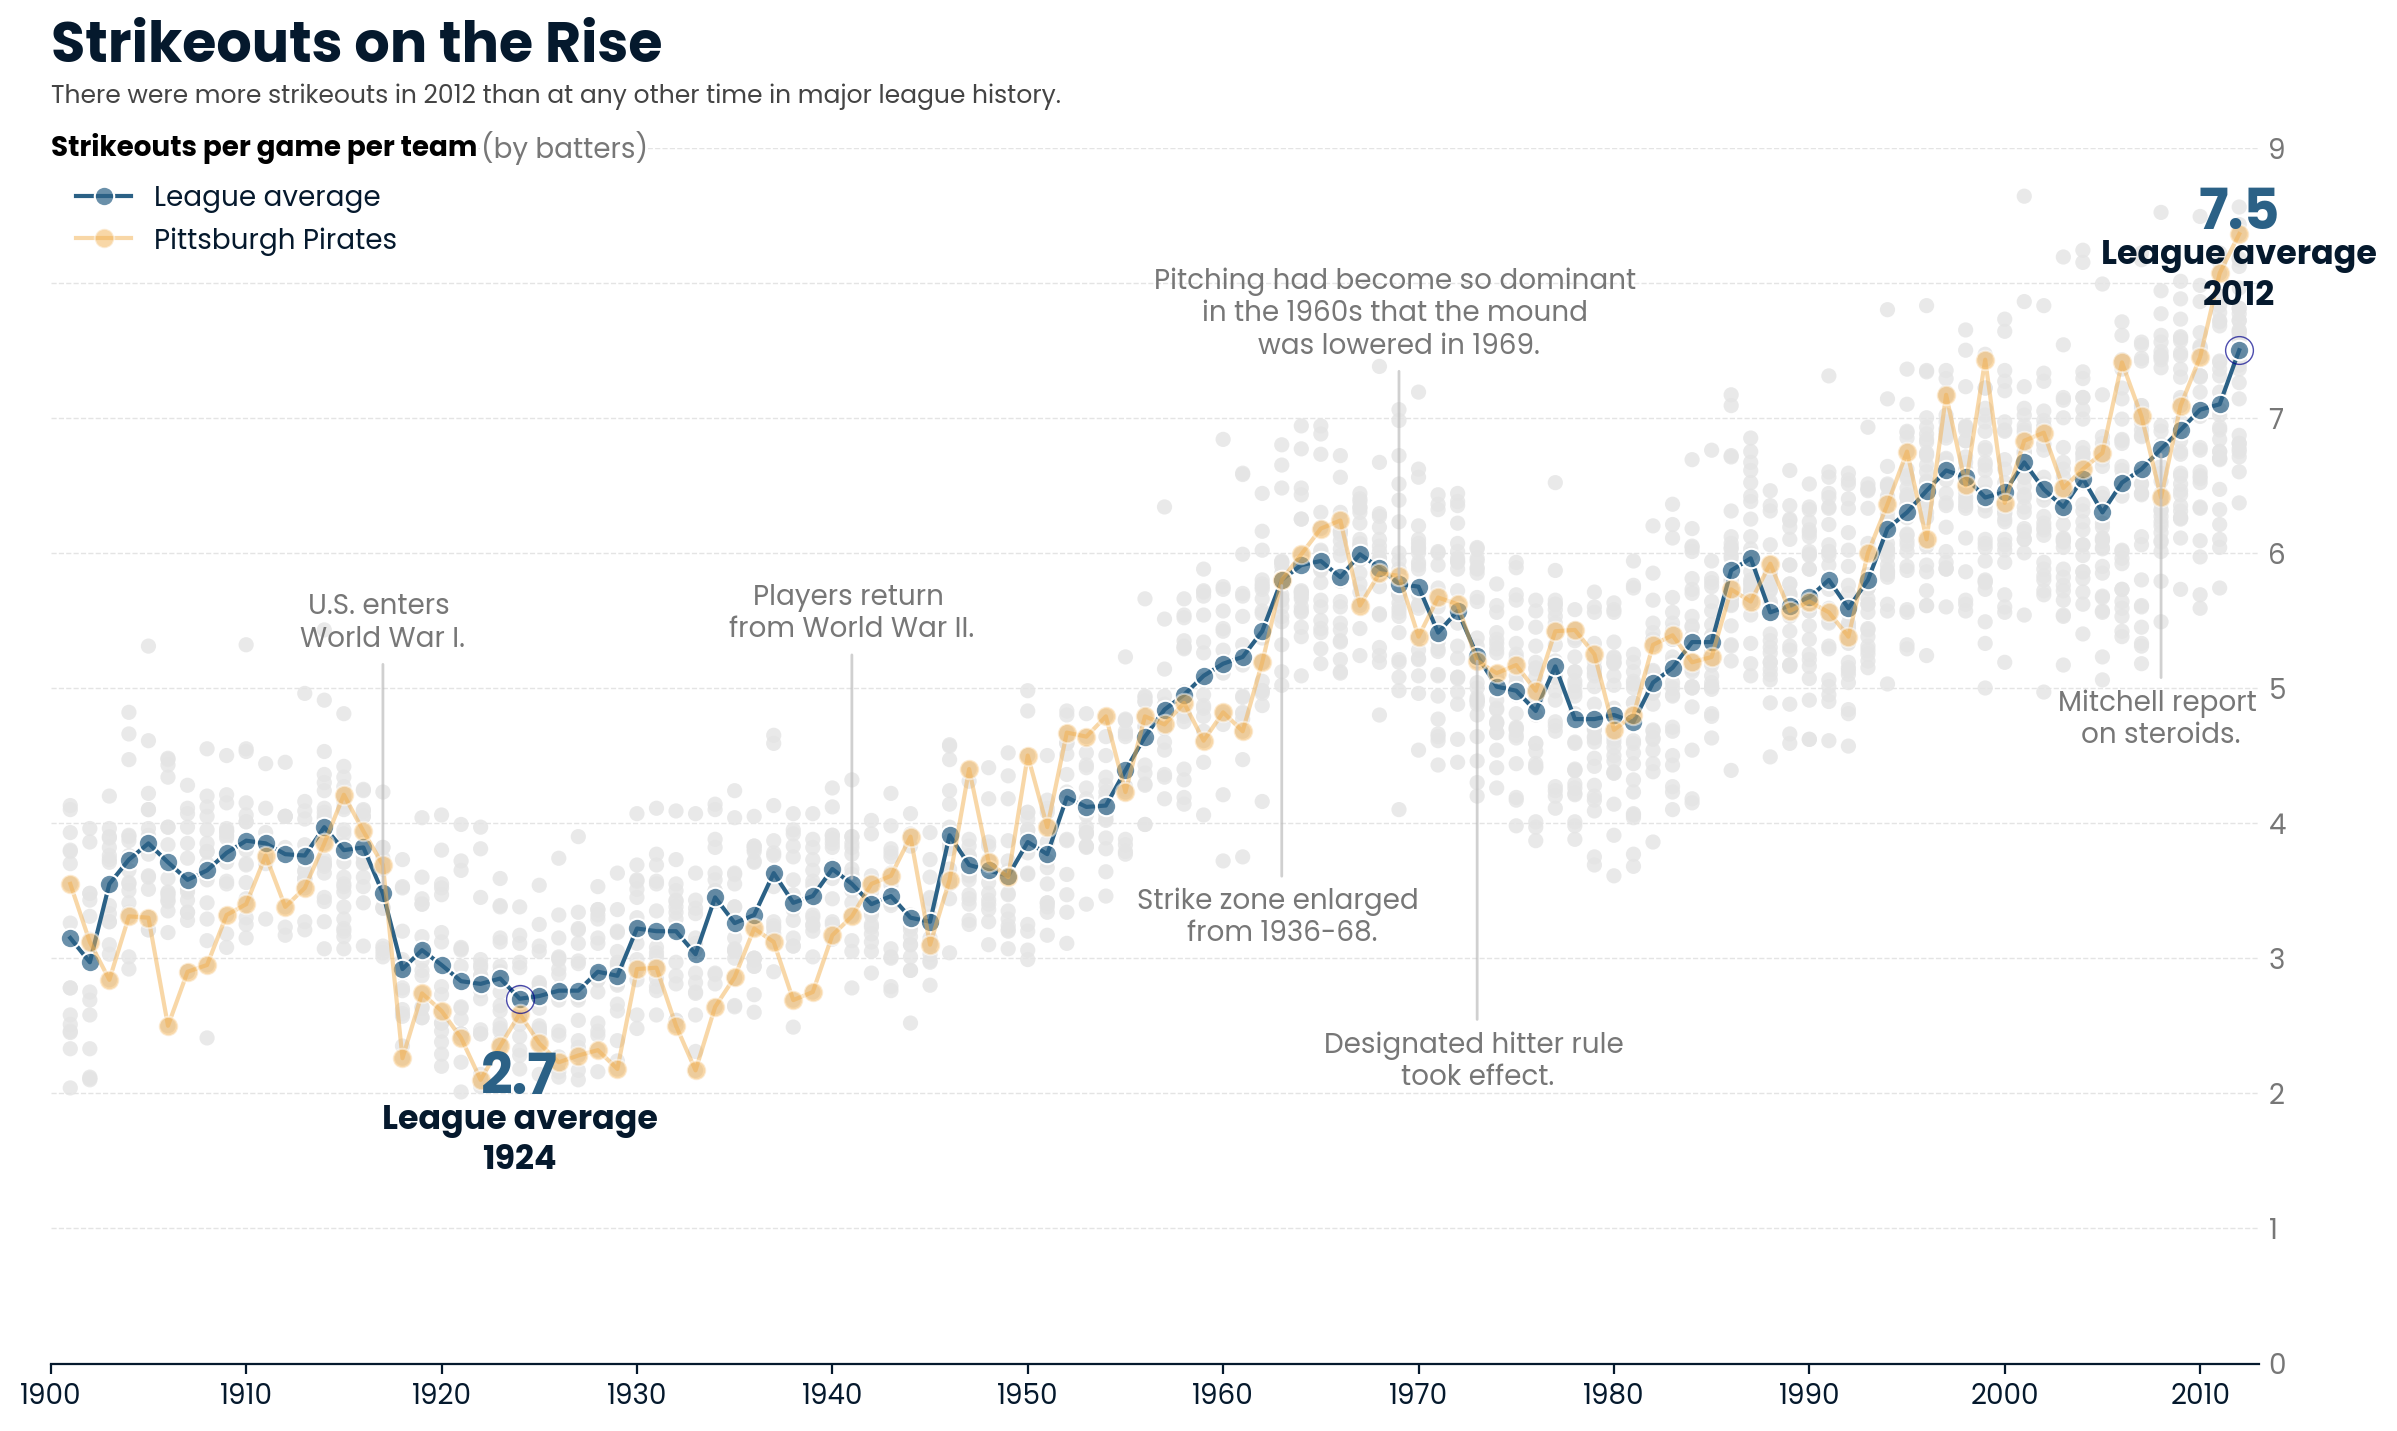

In [16]:
# margins and framing
fig, ax = plt.subplots(figsize=(12, 8))
fig.subplots_adjust(left=0.06, right=0.98)

# base layer of all teams data
sns.scatterplot(x="yearID", 
                    y="SO_per_G", 
                    data=teams_jittered, #using jitter df since its not built in scatterplot
                    color= '#e4e4e4',
                    alpha=0.8,
                    s=30,
                    edgecolor="none",)

# League average line in blue
sns.lineplot(x="yearID",
             y="avg_per_year",
             data=league_avg,
             marker="o",
             color= "#2b6186",
             markerfacecolor=(43/255, 97/255, 134/255, 0.7),
             markersize=7,
             label="League average")

# PIT
sns.lineplot(x="yearID",
             y="SO_per_G",
             data=PIT,
             marker="o",
             color= "#f2b050",
             markerfacecolor=(242/255, 176/255, 80/255, 0.7),
             markersize=7,
             alpha = 0.5,
             label="Pittsburgh Pirates")

## annotations
# general annotations
events = [
    {"year": 1917, "text": "U.S. enters \nWorld War I.", "dy": 2.0},
    {"year": 1941, "text": "Players return \nfrom World War II.", "dy": 2.0},
    {"year": 1963, "text": "Strike zone enlarged \nfrom 1936-68.", "dy": -2.5},
    {"year": 1969, "text": "Pitching had become so dominant \nin the 1960s that the mound \nwas lowered in 1969.", "dy": 2.0},
    {"year": 1973, "text": "Designated hitter rule \ntook effect.", "dy": -3.0},
    {"year": 2008, "text": "Mitchell report \non steroids.", "dy": -2.0},
]

ax = plt.gca()

for e in events:
    year = e["year"]

    # Get league average y-value for that year (league_avg has yearID as a column)
    y_series = league_avg.loc[league_avg["yearID"] == year, "avg_per_year"]
    if y_series.empty:
        continue  # skip if that year isn't present in your data
    y = float(y_series.iloc[0])

    dy = e["dy"]

    ax.annotate(
        e["text"],
        xy=(year, y),                 # point on the league average line
        xytext=(year, y + dy),        # label position (offset)
        ha="center",
        va="center",
        color="#777777",
        fontsize=10,
        arrowprops=dict(
            arrowstyle="-",           # line (no arrow head)
            color="#bdbdbd",
            alpha=0.7,                # MUST be a number, not a string
            linewidth=1
        )
    )

# big annotations
# 1917 average
year = 1924
y = league_avg.loc[league_avg["yearID"] == year, "avg_per_year"].iloc[0]

year2 = 2012
y2 = league_avg.loc[league_avg["yearID"] == year2, "avg_per_year"].iloc[0]

ax = plt.gca()

ax.text(year, y - 0.6, f"{y:.1f}", ha="center", va="center", fontsize=20, fontweight="bold", color="#2b6186")
ax.text(year, y - 0.9, "League average", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(year, y - 1.2, str(year), ha="center", va="center", fontsize=12, fontweight="bold")

ax.text(year2, y2 + 1.0, f"{y2:.1f}", ha="center", va="center", fontsize=20, fontweight="bold", color="#2b6186")
ax.text(year2, y2 + 0.7, "League average", ha="center", va="center", fontsize=12, fontweight="bold")
ax.text(year2, y2 + 0.4, str(year2), ha="center", va="center", fontsize=12, fontweight="bold")

## Title, Subtitle and legend
fig = ax.figure

# top space for title + subtitle
fig.subplots_adjust(top=0.87)

# Title
fig.text(
    0.06, 0.95,
    "Strikeouts on the Rise",
    ha="left", va="top",
    fontsize=20, fontweight="bold"
)
# Subtitle
fig.text(
    0.06, 0.91,
    "There were more strikeouts in 2012 than at any other time in major league history.",
    ha="left", va="top",
    fontsize=9, color="#444444"
)
# legend
legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0, 0.99),  # ↓ lower this number to move legend down
    frameon=False,
    fontsize=10
)

legend.set_title(None)

## aesthetics
# move y axis to the right
# y-axis on the right, no tick marks
ax.yaxis.tick_right()
ax.tick_params(axis="y", length=0, labelcolor="#777777")

# lock the y-axis scale
ax.set_ylim(0, 9)
ax.set_yticks(range(0, 10))  # 0–9 only

# hide labels for 8 and 9
for label in ax.get_yticklabels():
    if label.get_text() in ["8", "9"]:
        label.set_text("")

# remove x and y labels
ax.set_xlabel(None)
ax.set_ylabel(None)

# add x label on the upper left corner
ax.text(1900, 9, "Strikeouts per game per team", ha="left", va="center", fontsize=10, fontweight="bold", color="black", bbox=dict(facecolor="white", edgecolor="none", pad=0.2))
ax.text(1922, 9, "(by batters)", ha="left", va="center", fontsize=10, color="#777777", bbox=dict(facecolor="white", edgecolor="none", pad=0.2)) #im manually doing it but theres a longer code to ask plt to render

#despine (remove the frame) - have to do manually since it doesnt despine the left x axis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# add y axis grid
ax.grid(True, axis='y', linestyle='--', color='#e4e4e4', linewidth=0.5)

# x and y limit
ax.set_xlim(1900, 2013)
ax.set_xticks(range(1900,2020,10))

#circle border for big annotations points
plt.plot(
    year, y,
    marker='o',          # Circle marker
    markersize=10,       # Marker size
    markerfacecolor='None', # Fill color
    markeredgecolor=('darkblue',0.7),  # Border color
    markeredgewidth=0.5,   # Border width
    linestyle='None'        # Line style
)

plt.plot(
    year2, y2,
    marker='o',
    markersize=10,
    markerfacecolor='None',
    markeredgecolor=('darkblue',0.7),
    markeredgewidth=0.5,
    linestyle='None'
)

import matplotlib.ticker as mticker

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: "" if int(round(y)) == 8 else f"{int(y)}")
)

plt.show()

In [17]:
fig.savefig("baseball.png")